# Simple Actor-Critic (QAC) Method
- QAC (Q-Actor-Critic) refers to a specific variant of the actor-critic framework where the Critic uses the Action-Value function $Q(S, A)$  rather than the State-Value Function $V(s)$ to evaluate the action taken by the actor.

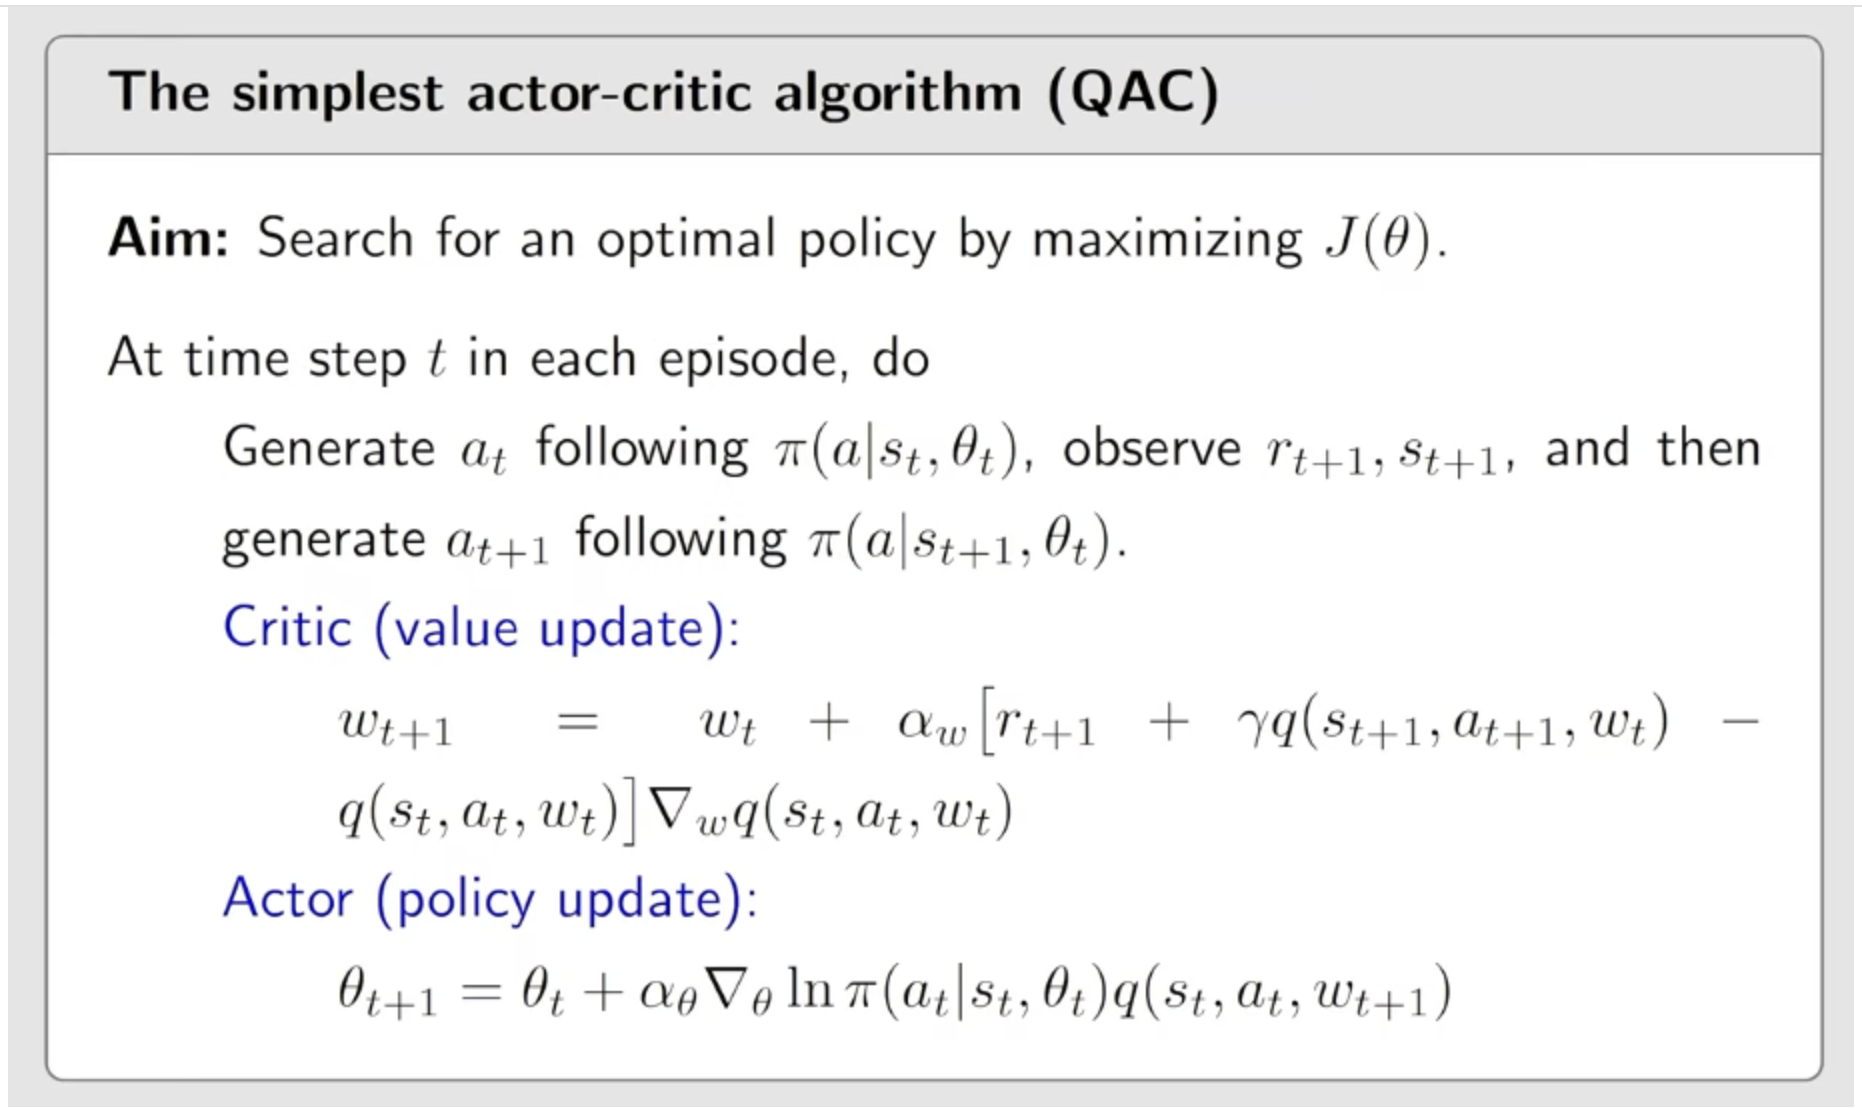

In [1]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque
from torch.distributions import Categorical

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
lake_grid = [["G", "H", "F", "F"],
             ["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "H", "S", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [3]:
class Actor(nn.Module):
    """
    Policy network π(a | s; θ).
    Outputs a categorical distribution over discrete actions.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), 
            nn.ReLU(),
            # nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> Categorical:
        logits = self.net(x)
        return Categorical(logits=logits)

    def log_prob(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.forward(x).log_prob(a)
            
    def policy_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        policy = np.zeros(env.n_states, dtype=np.int8)
        for state in states:
            state_vec = state.get_state_feature_vec(env.n_states)
            state_vec = torch.Tensor(state_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                action_probs = self.forward(state_vec).probs
                policy[state.idx] = torch.argmax(action_probs, dim=-1).item()
        return policy

In [4]:
actor = Actor(frozen_lake.n_states, frozen_lake.n_actions)
actor

Actor(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [5]:
state_vec = frozen_lake.find('S').get_state_feature_vec(frozen_lake.n_states)
state_vec = torch.Tensor(state_vec).unsqueeze(0)
state_vec.shape

torch.Size([1, 16])

In [6]:
print(actor(state_vec))
print(actor(state_vec).probs.shape)

Categorical(logits: torch.Size([1, 4]))
torch.Size([1, 4])


In [7]:
action = torch.tensor([1], dtype=torch.int64)
actor.log_prob(state_vec, action)

tensor([-1.3662], grad_fn=<SqueezeBackward1>)

In [8]:
actor.policy_table(frozen_lake)

array([0, 0, 0, 2, 0, 0, 0, 3, 3, 0, 0, 3, 0, 0, 1, 2], dtype=int8)

In [9]:
class Critic(nn.Module):
    """
    Q-value network Q(s, a; φ).
    Outputs one scalar per discrete action → index by chosen action.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), 
            nn.ReLU(),
            # nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns Q-values for all actions, shape (batch, act_dim)."""
        return self.net(x)

    def q_value(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """Returns Q(s, a) for a specific action index, shape (batch,)."""
        return self.forward(x).gather(1, a.unsqueeze(1)).squeeze(1)

    def q_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)
        for state in states:
            state_feat_vec = state.get_state_feature_vec(env.n_states)
            state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                q_values = self.forward(state_feat_vec).unsqueeze(0)    
            Q[state.idx, :] = q_values.detach().numpy()
        return Q

In [10]:
critic = Critic(frozen_lake.n_states, frozen_lake.n_actions)
critic

Critic(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [11]:
critic(state_vec)

tensor([[ 0.0652, -0.0144,  0.0882, -0.0780]], grad_fn=<AddmmBackward0>)

In [12]:
action

tensor([1])

In [13]:
critic.q_value(state_vec, action)

tensor([-0.0144], grad_fn=<SqueezeBackward1>)

In [14]:
critic.q_table(frozen_lake)

array([[ 0.05952493,  0.17898557,  0.13617846,  0.10277177],
       [ 0.11838612, -0.0136268 ,  0.03195369, -0.00365443],
       [ 0.01990238, -0.01960891,  0.12067574, -0.03865938],
       [ 0.0287601 ,  0.05943449,  0.09504788, -0.07976405],
       [ 0.02713659,  0.02598837,  0.17010373, -0.00871833],
       [ 0.14561112, -0.07712317,  0.06269734, -0.02683305],
       [ 0.07178354,  0.03101239,  0.11710078, -0.0205641 ],
       [-0.00992835,  0.0293746 ,  0.1348787 , -0.10637012],
       [ 0.05402564,  0.05080317,  0.01539867, -0.00945251],
       [-0.02509534,  0.14978035,  0.10972538, -0.01797315],
       [ 0.15225863,  0.04417808,  0.12812667, -0.08921483],
       [-0.02153748,  0.00776324,  0.11034705, -0.00999361],
       [-0.0145625 ,  0.1979152 ,  0.10090808, -0.087293  ],
       [-0.03791854,  0.01840763,  0.1615814 , -0.05758693],
       [ 0.06515853, -0.01444855,  0.0882291 , -0.07797243],
       [ 0.03358044,  0.06287865,  0.12514172, -0.00659987]],
      dtype=float32)

In [15]:
## QAC agent

In [16]:
class QACAgent:
    def __init__(self, env, actor, critic, lr_actor, lr_critic, gamma):
        self.env = env
        self.actor = actor
        self.critic = critic

        self.opt_actor  = optim.Adam(self.actor.parameters(),  lr=lr_actor)
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.gamma = gamma

    def critic_update(self, s, a, r, next_s, mask):
        # ----- compute target -----
        with torch.no_grad():
            actions_dist = self.actor(next_s)
            next_a = actions_dist.sample()
            q_next = self.critic.q_value(next_s, next_a)
            target  = r + self.gamma * q_next * mask
            
        q = self.critic.q_value(s, a)
        critic_loss = F.mse_loss(q, target) # td loss

        self.opt_critic.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.opt_critic.step()
        return critic_loss.item()

    def actor_update(self, s, a):
        log_prob = self.actor.log_prob(s, a)
        with torch.no_grad():
            q = self.critic.q_value(s, a)

        # print("log prob: ", log_prob, "q: ", q, "a: ", a)
        
        actor_loss = -(log_prob * q).mean()
        
        self.opt_actor.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)        
        self.opt_actor.step()
        return actor_loss.item()
    
    def update(self, s, a, r, next_s, done):
        s   = torch.FloatTensor(s).unsqueeze(0)    # (1, obs_dim)
        a   = torch.LongTensor([a])
        r   = torch.FloatTensor([r])
        next_s = torch.FloatTensor(next_s).unsqueeze(0)
        mask  = torch.FloatTensor([0.0 if done else 1.0])

        # ------- update critic ----------
        critic_loss = self.critic_update(s, a, r, next_s, mask)
        # ------- update actor ------------
        actor_loss = self.actor_update(s, a)

        return critic_loss, actor_loss

    @torch.no_grad()
    def sample_action(self, s, greedy=False):
        s  = torch.FloatTensor(s).unsqueeze(0)
        dist = self.actor(s)
        if greedy:
            return dist.probs.argmax(dim=-1).item()
        return dist.sample().item()

In [17]:
def train(env, n_episodes, gamma=0.99, lr_actor=1e-4, lr_critic=1e-4):
    actor = Actor(env.n_states, env.n_actions)
    critic = Critic(env.n_states, env.n_actions)
    agent = QACAgent(env, actor, critic, lr_actor, lr_critic, gamma)
    trajectory_histories = []
    policy_histories = []
    Q_histories = []
    for episode_idx in range(n_episodes):
        s = env.find('S')
        s_feat = s.get_state_feature_vec(env.n_states)
        a = agent.sample_action(s_feat)
        trajectory = []
        G  = 0
        while True:
            trajectory.append(s.coord)
            result = env.step(s, a)
            r = result["reward"]            
            next_s = result["new_state"]
            next_s_feat = next_s.get_state_feature_vec(env.n_states)
            is_terminated = result["is_terminated"]
            # print("s: ", s.coord, "a: ", a, "r:", r, "n_s: ", next_s.coord, "done: ", is_terminated)
    
            c_loss, a_loss = agent.update(s_feat, a, r, next_s_feat, is_terminated)
            
            s = next_s
            s_feat = next_s_feat
            a = agent.sample_action(s_feat)

            G += r
            if is_terminated:
                break

        trajectory_histories.append(trajectory)
        
        if episode_idx % 500 == 0:
            print("critic loss: ", c_loss, " actor loss: ", a_loss)
            print("Return: ", G)
            
            policy = agent.actor.policy_table(env)
            Q_table = agent.critic.q_table(env)
            policy_histories.append(policy)
            Q_histories.append(Q_table)
            # print("Q table", Q_table)
            # print("policy: ", policy)

    return policy_histories, Q_histories, trajectory_histories

In [18]:
lake_grid = [["G", "F", "F", "F"],
             ["F", "H", "H", "F"],
             ["F", "F", "F", "F"],
             ["H", "F", "S", "F"]]

# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 1,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [19]:
torch.autograd.set_detect_anomaly(True)

In [20]:
policy_histories, q_histories, trajectory_histories = train(frozen_lake, n_episodes=10000)
# trajectory_histories = train(frozen_lake, n_episodes=15000)

critic loss:  0.00405939482152462  actor loss:  -0.09343647956848145
Return:  0.0
critic loss:  1.7739656641424517e-06  actor loss:  -0.0018830595072358847
Return:  0.0
critic loss:  0.9206601977348328  actor loss:  0.050077591091394424
Return:  1.0
critic loss:  0.00046072102850303054  actor loss:  0.028509287163615227
Return:  0.0
critic loss:  0.24590106308460236  actor loss:  0.10203247517347336
Return:  1.0
critic loss:  0.009394976310431957  actor loss:  0.11138498038053513
Return:  0.0
critic loss:  0.031374454498291016  actor loss:  0.5929335355758667
Return:  0.0
critic loss:  0.9630990624427795  actor loss:  0.031363263726234436
Return:  0.0
critic loss:  0.060821086168289185  actor loss:  0.7125667929649353
Return:  0.0
critic loss:  0.6391984224319458  actor loss:  0.012549130246043205
Return:  0.0
critic loss:  0.00301487953402102  actor loss:  0.004182048141956329
Return:  1.0
critic loss:  0.7583982348442078  actor loss:  0.002370103495195508
Return:  0.0
critic loss:  0

In [21]:
policy = policy_histories[-1]
q_table = q_histories[-1]

In [22]:
policy

array([0, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0], dtype=int8)

In [23]:
q_table

array([[0.7403101 , 0.6889363 , 0.6142607 , 0.5539198 ],
       [0.98407465, 0.6666293 , 0.6552205 , 0.647426  ],
       [0.6501872 , 0.5499315 , 0.62866235, 0.57861996],
       [0.56786513, 0.5655881 , 0.6142509 , 0.5458389 ],
       [0.8891736 , 0.698066  , 0.62279296, 0.97074926],
       [0.7407331 , 0.6097734 , 0.6198746 , 0.5240982 ],
       [0.78189707, 0.58498335, 0.5861052 , 0.57397866],
       [0.26356694, 0.47623444, 0.51745665, 0.49835068],
       [0.8400898 , 0.61259115, 0.6645211 , 0.9281737 ],
       [0.8625715 , 0.70843035, 0.64922583, 0.26251817],
       [0.815527  , 0.7064582 , 0.60815537, 0.31939864],
       [0.7622091 , 0.7607248 , 0.72594583, 0.58242023],
       [0.8017534 , 0.71829164, 0.65904427, 0.48823458],
       [0.49898976, 0.6119047 , 0.6437725 , 0.8003896 ],
       [0.792101  , 0.7805453 , 0.78719544, 0.80063486],
       [0.78109103, 0.7380928 , 0.7323202 , 0.7116304 ]], dtype=float32)

In [24]:
# Render policy

In [25]:
import pandas as pd
from IPython.display import display

In [26]:
# trajectory_histories

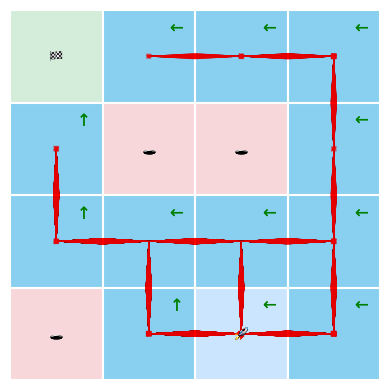

In [27]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)